<a href="https://www.kaggle.com/code/michelepulvirenti/houseplant-recognition?scriptVersionId=267862274" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import random
from tqdm import tqdm
import numpy as np
from PIL import Image
import math

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

2025-10-13 19:04:36.550831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760382276.811520      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760382276.872841      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Parameters

In [2]:
batch_size = 32
image_size = 256
dataset_dir = '/kaggle/input/house-plant-species/house_plant_species'

# Dataset loading

In [3]:
# --- Image preprocessing ---
def preprocess_pil_image(pil_img):
    # Handle images with palette or transparency
    if pil_img.mode in ("P", "RGBA"):
        pil_img = pil_img.convert("RGBA")  # Preserve transparency if needed
        # Convert RGBA → RGB by compositing on white background
        background = Image.new("RGBA", pil_img.size, (255, 255, 255, 255))
        pil_img = Image.alpha_composite(background, pil_img).convert("RGB")
    elif pil_img.mode != "RGB":
        pil_img = pil_img.convert("RGB")

    img_resized = pil_img.resize((image_size, image_size))
    img_array = np.array(img_resized)
    return img_array



# --- Load dataset directly from Kaggle directory ---
class_names = sorted(os.listdir(dataset_dir))
class_to_id = {name: i for i, name in enumerate(class_names)}

print("🌿 Found classes:", class_names)

images, labels = [], []

# Loop through folders and images
for class_name in tqdm(class_names, desc="Preprocessing data"):
    class_path = os.path.join(dataset_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            pil_image = Image.open(img_path)
            img_pp = preprocess_pil_image(pil_image)
            images.append(img_pp)
            labels.append(class_to_id[class_name])
        except Exception as e:
            print(f"⚠️ Failed to process image {img_path}: {e}")

images = np.array(images)
labels = np.array(labels)

print(f"✅ Preprocessed and saved dataset.\nImages shape: {images.shape}, labels shape: {labels.shape}")

🌿 Found classes: ['African Violet (Saintpaulia ionantha)', 'Aloe Vera', 'Anthurium (Anthurium andraeanum)', 'Areca Palm (Dypsis lutescens)', 'Asparagus Fern (Asparagus setaceus)', 'Begonia (Begonia spp.)', 'Bird of Paradise (Strelitzia reginae)', 'Birds Nest Fern (Asplenium nidus)', 'Boston Fern (Nephrolepis exaltata)', 'Calathea', 'Cast Iron Plant (Aspidistra elatior)', 'Chinese Money Plant (Pilea peperomioides)', 'Chinese evergreen (Aglaonema)', 'Christmas Cactus (Schlumbergera bridgesii)', 'Chrysanthemum', 'Ctenanthe', 'Daffodils (Narcissus spp.)', 'Dracaena', 'Dumb Cane (Dieffenbachia spp.)', 'Elephant Ear (Alocasia spp.)', 'English Ivy (Hedera helix)', 'Hyacinth (Hyacinthus orientalis)', 'Iron Cross begonia (Begonia masoniana)', 'Jade plant (Crassula ovata)', 'Kalanchoe', 'Lilium (Hemerocallis)', 'Lily of the valley (Convallaria majalis)', 'Money Tree (Pachira aquatica)', 'Monstera Deliciosa (Monstera deliciosa)', 'Orchid', 'Parlor Palm (Chamaedorea elegans)', 'Peace lily', 'Poins

Preprocessing data: 100%|██████████| 47/47 [12:51<00:00, 16.41s/it]


✅ Preprocessed and saved dataset.
Images shape: (14790, 256, 256, 3), labels shape: (14790,)


# Dataset info

In [4]:
unique_labels, counts = np.unique(labels, return_counts=True)
print("Labels distribution:", dict(zip(unique_labels, counts)))

num_classes = len(set(labels))
print("Number of classes:", num_classes)

Labels distribution: {0: 337, 1: 252, 2: 455, 3: 189, 4: 169, 5: 236, 6: 180, 7: 290, 8: 307, 9: 330, 10: 266, 11: 382, 12: 514, 13: 312, 14: 209, 15: 347, 16: 421, 17: 261, 18: 541, 19: 332, 20: 240, 21: 318, 22: 266, 23: 353, 24: 130, 25: 480, 26: 416, 27: 359, 28: 547, 29: 234, 30: 329, 31: 385, 32: 306, 33: 341, 34: 197, 35: 243, 36: 400, 37: 316, 38: 291, 39: 202, 40: 326, 41: 396, 42: 341, 43: 341, 44: 199, 45: 66, 46: 438}
Number of classes: 47


In [5]:
# print("Displaying one sample per label:")
# fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

# if len(unique_labels) == 1:
#     axes = [axes]  # Handle single-class edge case

# for i, label_id in enumerate(unique_labels):
#     # Find the first sample index for this label
#     idx = np.where(labels == label_id)[0][0]
#     img = images[idx]

#     axes[i].imshow(img)
#     axes[i].set_title(class_names[label_id])
#     axes[i].axis("off")

# plt.tight_layout()
# plt.show()

# Training

In [6]:
labels_cat = to_categorical(labels, num_classes=num_classes)

# Step 3: Train-test split for validation
X_train, X_val, y_train, y_val = train_test_split(images, labels_cat, test_size=0.2, random_state=42, stratify=labels)

## Model

In [7]:
# Step 4: Build the model (Transfer Learning)

base_model = EfficientNetV2B0(
    input_shape=(image_size, image_size, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False  # Freeze base model

inputs = layers.Input(shape=(image_size, image_size, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=loss,
              metrics=['accuracy'])

model.summary()

I0000 00:00:1760383065.759380      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 47)             │        60,207 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,979,519 (22.81 MB)

 Trainable params: 60,207 (235.18 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Data augmentation

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),

    layers.RandomZoom(0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.15),
    layers.RandomSaturation(0.15),

    layers.RandomHue(0.05),

    layers.GaussianNoise(0.02)
])


# Using augmentation in a dataset pipeline
def augment_and_preprocess(img):
    img = data_augmentation(tf.cast(img, tf.float32))
    img = preprocess_input(img)
    return img

# If you prepare a tf.data.Dataset (recommended for large datasets):
# Assuming X_train, y_train are NumPy arrays of images and labels
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=1024)
train_dataset = train_dataset.map(
    lambda x, y: (augment_and_preprocess(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# For validation, do NOT apply augmentation:
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [9]:
# sample_images, sample_labels = next(iter(train_dataset.unbatch().batch(batch_size)))

# plt.figure(figsize=(10, 10))

# num_samples = len(sample_images)
# cols = 4
# rows = math.ceil(num_samples / cols)

# for i in range(num_samples):
#     plt.subplot(rows, cols, i + 1)
#     img = np.clip(sample_images[i].numpy() / 255.0, 0, 1)
#     plt.imshow(img)
#     plt.title(f"Label: {np.argmax(sample_labels[i])}")
#     plt.axis("off")

# plt.suptitle("Sample Training Images (with Augmentation)", fontsize=14)
# plt.tight_layout()
# plt.show()


## Training model

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# When training, use train_dataset and val_dataset instead of NumPy arrays
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


I0000 00:00:1760383096.485635      60 service.cc:148] XLA service 0x7efb2c003440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760383096.486627      60 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1760383099.106062      60 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/370 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.0278 - loss: 4.0230   

I0000 00:00:1760383109.872123      60 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


370/370 ━━━━━━━━━━━━━━━━━━━━ 183s 409ms/step - accuracy: 0.2644 - loss: 3.1130 - val_accuracy: 0.5470 - val_loss: 2.1967
Epoch 2/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 130s 352ms/step - accuracy: 0.5729 - loss: 2.0756 - val_accuracy: 0.6207 - val_loss: 1.9318
Epoch 3/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 132s 356ms/step - accuracy: 0.6235 - loss: 1.9148 - val_accuracy: 0.6700 - val_loss: 1.8170
Epoch 4/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 131s 354ms/step - accuracy: 0.6501 - loss: 1.8408 - val_accuracy: 0.6829 - val_loss: 1.7692
Epoch 5/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 131s 354ms/step - accuracy: 0.6702 - loss: 1.7727 - val_accuracy: 0.7032 - val_loss: 1.7230
Epoch 6/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 132s 355ms/step - accuracy: 0.6824 - loss: 1.7418 - val_accuracy: 0.7143 - val_loss: 1.6891
Epoch 7/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 131s 355ms/step - accuracy: 0.6937 - loss: 1.7049 - val_accuracy: 0.7113 - val_loss: 1.6723
Epoch 8/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 131s 354ms/step - accuracy: 0.6907 - loss: 1.71

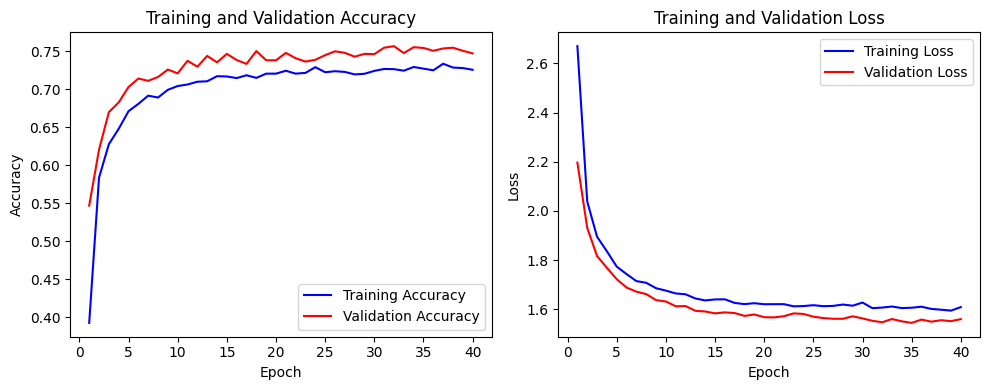

In [11]:
# Extract metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
print(f"Training Accuracy: {acc[-1]:.4f}")
print(f"Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Training Loss: {loss[-1]:.4f}")
print(f"Validation Loss: {val_loss[-1]:.4f}")

Training Accuracy: 0.7258
Validation Accuracy: 0.7475
Training Loss: 1.6095
Validation Loss: 1.5607


In [13]:
# Step 6: Fine-tune the base model by unfreezing some layers
base_model.trainable = True
# Unfreeze only the top layers of base model for fine-tuning
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_fine = model.fit(train_dataset,
                         validation_data=val_dataset,
                         epochs=50,
                         callbacks=[early_stop])

Epoch 1/50


E0000 00:00:1760388464.377475      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760388464.567132      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760388465.000429      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760388465.207276      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


369/370 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7052 - loss: 1.0595

E0000 00:00:1760388623.442425      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760388623.629201      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760388624.046771      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1760388624.256188      60 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


370/370 ━━━━━━━━━━━━━━━━━━━━ 238s 464ms/step - accuracy: 0.7054 - loss: 1.0585 - val_accuracy: 0.8634 - val_loss: 0.5060
Epoch 2/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 142s 382ms/step - accuracy: 0.8301 - loss: 0.5606 - val_accuracy: 0.8766 - val_loss: 0.4220
Epoch 3/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 142s 384ms/step - accuracy: 0.8688 - loss: 0.4236 - val_accuracy: 0.8874 - val_loss: 0.4005
Epoch 4/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 145s 391ms/step - accuracy: 0.8891 - loss: 0.3513 - val_accuracy: 0.8935 - val_loss: 0.3990
Epoch 5/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 146s 395ms/step - accuracy: 0.8993 - loss: 0.3206 - val_accuracy: 0.9040 - val_loss: 0.3631
Epoch 6/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 146s 393ms/step - accuracy: 0.9107 - loss: 0.2828 - val_accuracy: 0.9094 - val_loss: 0.3762
Epoch 7/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 144s 389ms/step - accuracy: 0.9222 - loss: 0.2470 - val_accuracy: 0.8966 - val_loss: 0.4051
Epoch 8/50
370/370 ━━━━━━━━━━━━━━━━━━━━ 144s 388ms/step - accuracy: 0.9243 - loss: 0.23

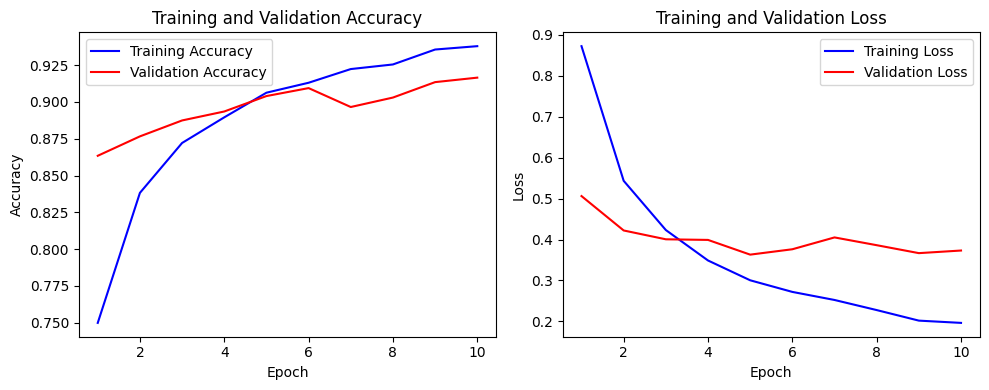

In [14]:
# Extract metrics
acc_fine = history_fine.history['accuracy']
val_acc_fine = history_fine.history['val_accuracy']
loss_fine = history_fine.history['loss']
val_loss_fine = history_fine.history['val_loss']

epochs = range(1, len(acc_fine) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc_fine, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc_fine, 'r-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss_fine, 'b-', label='Training Loss')
plt.plot(epochs, val_loss_fine, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [15]:
print(f"Final Training Accuracy: {acc_fine[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc_fine[-1]:.4f}")
print(f"Final Training Loss: {loss_fine[-1]:.4f}")
print(f"Final Validation Loss: {val_loss_fine[-1]:.4f}")

Final Training Accuracy: 0.9379
Final Validation Accuracy: 0.9165
Final Training Loss: 0.1965
Final Validation Loss: 0.3731


# Saving model

In [16]:
# Step 7: Export model to a TensorFlow SavedModel directory
MODEL_DIR = '/kaggle/working/houseplant_classifier_model'  # no .keras extension
model.export(MODEL_DIR)  # creates a folder with saved_model.pb etc.

# Step 8: Convert to TensorFlow Lite model
converter = tf.lite.TFLiteConverter.from_saved_model(MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('/kaggle/working/houseplant_classifier_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ TensorFlow Lite model saved as houseplant_classifier_model.tflite")

Saved artifact at '/kaggle/working/houseplant_classifier_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_271')
Output Type:
  TensorSpec(shape=(None, 47), dtype=tf.float32, name=None)
Captures:
  139626041921936: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139626041921744: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139626041922128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626041923856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626041922512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626056872016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626041920784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626041924048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626041923472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139626041923088: TensorSpec(shape=

W0000 00:00:1760390002.325643      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1760390002.325696      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1760390002.521002      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


✅ TensorFlow Lite model saved as houseplant_classifier_model.tflite
